In [6]:
import pandas as pd

# Load the dataset
df_geo = pd.read_csv("olist_geolocation_dataset.csv")

# Display basic info and first few rows
print("Shape:", df_geo.shape)
print("Columns:", df_geo.columns.tolist())
print("\nUnique States:", df_geo['geolocation_state'].nunique())

Shape: (1000163, 5)
Columns: ['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state']

Unique States: 27


In [8]:
df_geo.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


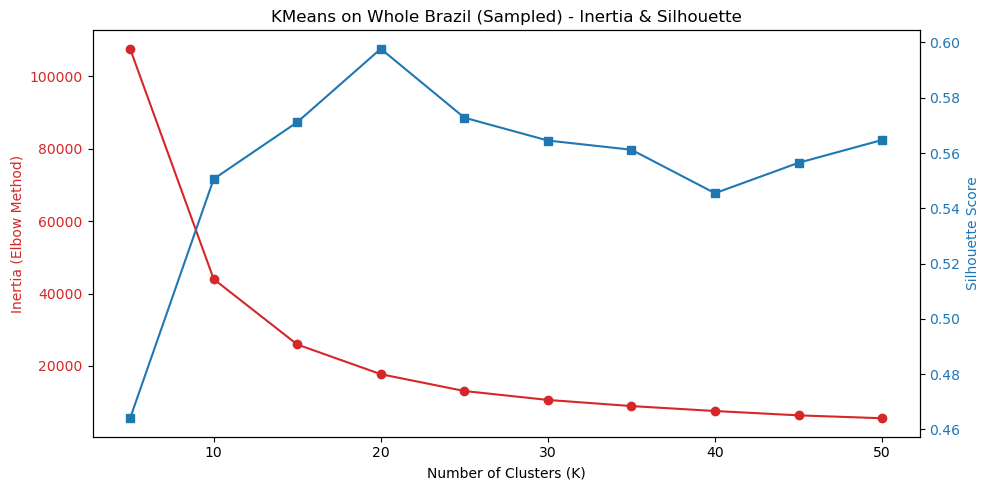

Best K by Silhouette (Brazil): 20


In [10]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

df_geo = pd.read_csv("olist_geolocation_dataset.csv")

# Drop duplicates to get unique coordinates (roughly unique locations)
df_unique = df_geo.drop_duplicates(subset=['geolocation_lat', 'geolocation_lng'])

# Sample 10000 points for performance in Silhouette
df_sample = df_unique.sample(n=10000, random_state=42)
X = df_sample[['geolocation_lat', 'geolocation_lng']].values

k_values = range(5, 51, 5)
inertias = []
sil_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    inertias.append(kmeans.inertia_)
    score = silhouette_score(X, labels)
    sil_scores.append(score)

# Plotting
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:red'
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia (Elbow Method)', color=color)
ax1.plot(k_values, inertias, color=color, marker='o')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('Silhouette Score', color=color)  
ax2.plot(k_values, sil_scores, color=color, marker='s')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('KMeans on Whole Brazil (Sampled) - Inertia & Silhouette')
fig.tight_layout()  
plt.savefig('brazil_kmeans_eval.png')
plt.show()

print("Best K by Silhouette (Brazil):", k_values[np.argmax(sil_scores)])

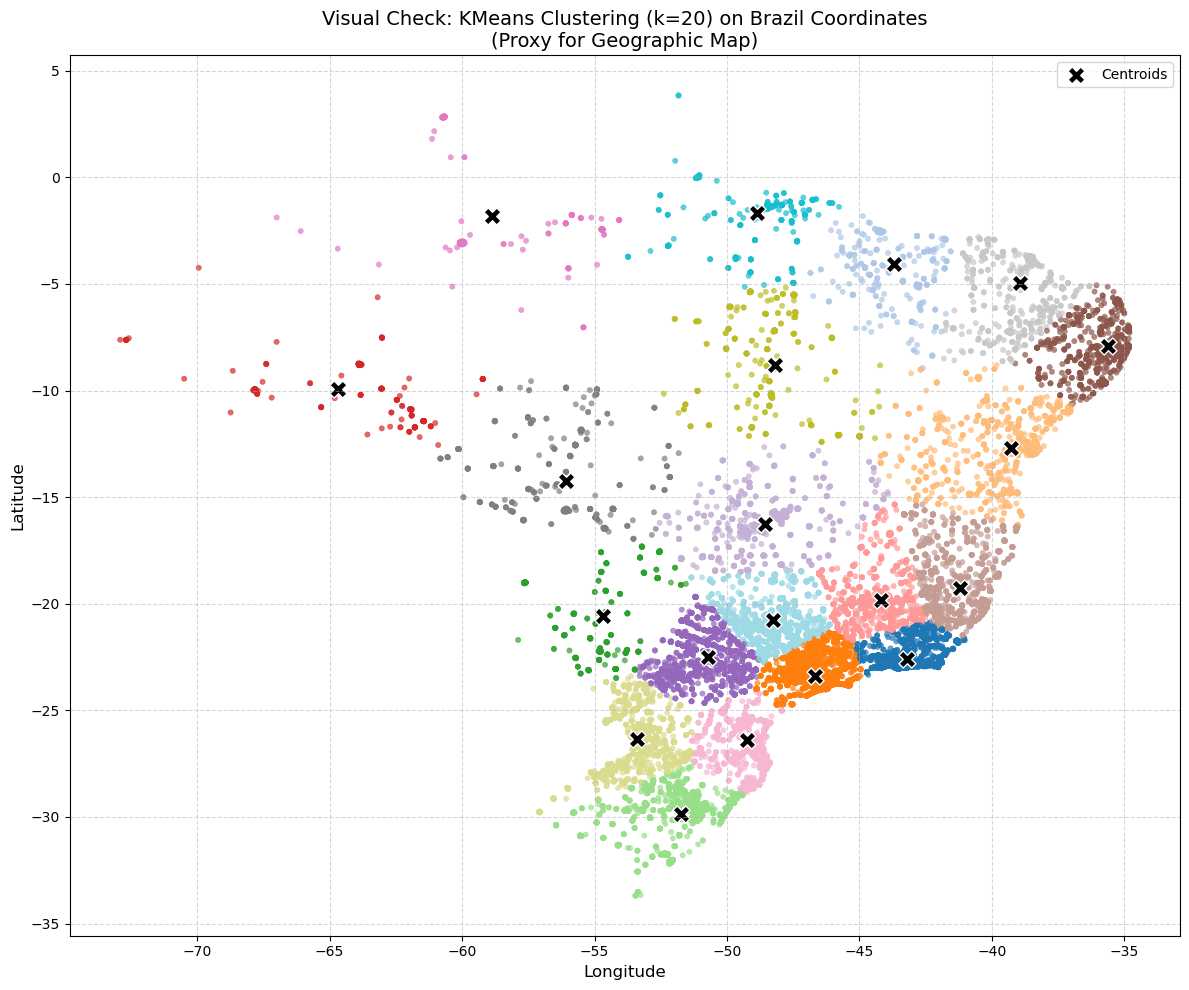

Thống kê Bán kính các cụm (km) với k=20:
- Bán kính cụm lớn nhất: 939.25 km
- Bán kính cụm nhỏ nhất: 237.75 km
- Bán kính trung bình các cụm: 169.96 km


In [12]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load and clean data
df_geo = pd.read_csv("olist_geolocation_dataset.csv")

# Filter points that are actually within Brazil's approximate bounding box to remove outliers
# Brazil bounds roughly: lat -35 to 5, lng -75 to -30
df_geo = df_geo[(df_geo['geolocation_lat'] >= -35) & (df_geo['geolocation_lat'] <= 5) &
                (df_geo['geolocation_lng'] >= -75) & (df_geo['geolocation_lng'] <= -30)]
                
df_unique = df_geo.drop_duplicates(subset=['geolocation_lat', 'geolocation_lng'])

# Sample 50,000 points for clear visualization and speed
df_sample = df_unique.sample(n=50000, random_state=42).copy()
X = df_sample[['geolocation_lat', 'geolocation_lng']].values

# 2. Run KMeans with k=20
k = 20
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df_sample['cluster'] = kmeans.fit_predict(X)
centroids = kmeans.cluster_centers_

# 3. Visualization
plt.figure(figsize=(12, 10))
sns.scatterplot(
    x='geolocation_lng', y='geolocation_lat', 
    hue='cluster', palette='tab20', data=df_sample, 
    s=15, edgecolor=None, legend=False, alpha=0.7
)
# Plot centroids
plt.scatter(centroids[:, 1], centroids[:, 0], c='black', marker='X', s=150, label='Centroids', edgecolor='white')
plt.title(f'Visual Check: KMeans Clustering (k={k}) on Brazil Coordinates\n(Proxy for Geographic Map)', fontsize=14)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('brazil_map_k20_visual.png')
plt.show()

# 4. Calculate Radius (Haversine distance in km) to assess risk
def haversine_dist(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a = np.sin(dlat/2)**2 + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    return R * c

max_radii = []
mean_radii = []

for i in range(k):
    cluster_points = df_sample[df_sample['cluster'] == i]
    center_lat, center_lng = centroids[i]
    
    dists = haversine_dist(cluster_points['geolocation_lat'].values, 
                           cluster_points['geolocation_lng'].values, 
                           center_lat, center_lng)
    max_radii.append(dists.max())
    mean_radii.append(dists.mean())

print(f"Thống kê Bán kính các cụm (km) với k={k}:")
print(f"- Bán kính cụm lớn nhất: {max(max_radii):.2f} km")
print(f"- Bán kính cụm nhỏ nhất: {min(max_radii):.2f} km")
print(f"- Bán kính trung bình các cụm: {np.mean(mean_radii):.2f} km")

In [14]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import requests
import time
from IPython.display import display

# 1. Tải và làm sạch dữ liệu
print("1. Đang tải và lọc dữ liệu tọa độ...")
df_geo = pd.read_csv("olist_geolocation_dataset.csv")

# Lọc các tọa độ nằm trong ranh giới địa lý gần đúng của Brazil để loại bỏ nhiễu
df_geo = df_geo[(df_geo['geolocation_lat'] >= -35) & (df_geo['geolocation_lat'] <= 5) &
                (df_geo['geolocation_lng'] >= -75) & (df_geo['geolocation_lng'] <= -30)]

# Lấy tọa độ unique để chạy thuật toán phân cụm nhanh hơn
df_unique = df_geo.drop_duplicates(subset=['geolocation_lat', 'geolocation_lng']).copy()
X = df_unique[['geolocation_lat', 'geolocation_lng']].values

# 2. Chạy KMeans với k=20
print("2. Đang chạy mô hình KMeans (k=20)...")
kmeans = KMeans(n_clusters=20, random_state=42, n_init=10)
df_unique['cluster'] = kmeans.fit_predict(X)
centroids = kmeans.cluster_centers_

# Hàm tính khoảng cách bề mặt Trái Đất (Haversine) theo km
def haversine_dist(lat1, lon1, lat2, lon2):
    R = 6371 
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a = np.sin(dlat/2)**2 + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    return R * c

# 3. Tìm Cluster lớn nhất và xác định các điểm ranh giới
print("3. Đang tính toán bán kính các cụm để tìm cụm lớn nhất...")
max_radii = []
for i in range(20):
    cluster_points = df_unique[df_unique['cluster'] == i]
    if len(cluster_points) > 0:
        dists = haversine_dist(cluster_points['geolocation_lat'].values, 
                               cluster_points['geolocation_lng'].values, 
                               centroids[i][0], centroids[i][1])
        max_radii.append((i, dists.max()))

largest_cluster_id = max(max_radii, key=lambda x: x[1])[0]
c_lat, c_lng = centroids[largest_cluster_id]
print(f"   -> Cluster lớn nhất là ID: {largest_cluster_id} với Bán kính lớn nhất: {max(max_radii, key=lambda x: x[1])[1]:.2f} km\n")

# Trích xuất tọa độ của tâm cụm và 2 điểm xa nhất trong cụm đó
cluster_points = df_unique[df_unique['cluster'] == largest_cluster_id].copy()
cluster_points['dist_to_centroid'] = haversine_dist(cluster_points['geolocation_lat'].values, 
                                                    cluster_points['geolocation_lng'].values, 
                                                    c_lat, c_lng)
furthest_points = cluster_points.nlargest(2, 'dist_to_centroid')

points_to_check = [
    {"name": "Tâm cụm (Centroid)", "lat": c_lat, "lng": c_lng, "dist_km": 0},
    {"name": "Điểm ranh giới 1 (Bắc)", "lat": furthest_points.iloc[0]['geolocation_lat'], "lng": furthest_points.iloc[0]['geolocation_lng'], "dist_km": furthest_points.iloc[0]['dist_to_centroid']},
    {"name": "Điểm ranh giới 2 (Nam)", "lat": furthest_points.iloc[1]['geolocation_lat'], "lng": furthest_points.iloc[1]['geolocation_lng'], "dist_km": furthest_points.iloc[1]['dist_to_centroid']}
]

# 4. Truy xuất dữ liệu thời tiết thực tế từ Open-Meteo Archive API
# Chọn 2 ngày đại diện: 1 ngày mùa mưa (Tháng 1) và 1 ngày mùa khô (Tháng 7) năm 2018
dates_to_check = ["2018-01-15", "2018-07-15"]
results = []

print("4. Đang gửi request gọi API Open-Meteo Historical (Vui lòng đợi vài giây để tránh rate limit)...")
for date in dates_to_check:
    for p in points_to_check:
        # Lấy thông số nhiệt độ và lượng mưa theo giờ, múi giờ Sao Paulo
        url = f"https://archive-api.open-meteo.com/v1/archive?latitude={p['lat']}&longitude={p['lng']}&start_date={date}&end_date={date}&hourly=temperature_2m,precipitation&timezone=America/Sao_Paulo"
        
        try:
            r = requests.get(url)
            if r.status_code == 200:
                data = r.json()
                hourly = data['hourly']
                
                # Tổng hợp các thông số quan trọng trong ngày
                temp_max = max(hourly['temperature_2m'])
                temp_min = min(hourly['temperature_2m'])
                total_precip = sum(hourly['precipitation'])
                
                # Lấy dữ liệu lượng mưa tại thời điểm 15:00 (giờ giao hàng cao điểm)
                idx_15 = 15
                precip_15 = hourly['precipitation'][idx_15]
                
                results.append({
                    "Ngày": date,
                    "Vị trí": p['name'],
                    "Khoảng cách đến tâm (km)": round(p['dist_km'], 1),
                    "Nhiệt độ Max/Min (°C)": f"{temp_max} / {temp_min}",
                    "Tổng lượng mưa (mm)": round(total_precip, 2),
                    "Mưa lúc 15:00 (mm)": precip_15
                })
            else:
                print(f"   [!] Lỗi API cho {p['name']} vào ngày {date}: Mã lỗi {r.status_code}")
        except Exception as e:
            print(f"   [!] Lỗi kết nối mạng: {e}")
            
        time.sleep(1) # Delay 1s giữa mỗi request để tôn trọng chính sách free tier của Open-Meteo

# 5. Hiển thị kết quả dưới dạng bảng
print("\n5. KẾT QUẢ SO SÁNH THỜI TIẾT TRONG CÙNG 1 ZONE (K=20):")
df_weather = pd.DataFrame(results)

# Render bảng đẹp trong Jupyter Notebook
display(df_weather)

1. Đang tải và lọc dữ liệu tọa độ...
2. Đang chạy mô hình KMeans (k=20)...
3. Đang tính toán bán kính các cụm để tìm cụm lớn nhất...
   -> Cluster lớn nhất là ID: 14 với Bán kính lớn nhất: 954.98 km

4. Đang gửi request gọi API Open-Meteo Historical (Vui lòng đợi vài giây để tránh rate limit)...

5. KẾT QUẢ SO SÁNH THỜI TIẾT TRONG CÙNG 1 ZONE (K=20):


,Ngày,Vị trí,Khoảng cách đến tâm (km),Nhiệt độ Max/Min (°C),Tổng lượng mưa (mm),Mưa lúc 15:00 (mm)
0,2018-01-15,Tâm cụm (Centroid),0.0,28.0 / 21.8,10.1,2.2
1,2018-01-15,Điểm ranh giới 1 (Bắc),955.0,30.5 / 24.3,4.1,0.0
2,2018-01-15,Điểm ranh giới 2 (Nam),954.6,30.5 / 24.3,4.1,0.0
3,2018-07-15,Tâm cụm (Centroid),0.0,28.3 / 22.2,3.8,0.9
4,2018-07-15,Điểm ranh giới 1 (Bắc),955.0,29.4 / 23.2,2.7,0.5
5,2018-07-15,Điểm ranh giới 2 (Nam),954.6,29.4 / 23.2,2.7,0.5


1. Đang tải dữ liệu...
2. Đang map hàng trăm ngàn tọa độ sang H3 Index (Resolution = 5)...

[Kết quả] Tổng số Zone (H3 Hexagons) được tạo ra: 6853

Top 5 Zone chứa nhiều điểm tọa độ (đơn hàng) nhất:


,h3_zone,point_count
0,85a8100ffffffff,33923
1,85a81073fffffff,18842
2,85a81007fffffff,18083
3,85a88cdbfffffff,17649
4,85a8100bfffffff,15601



4. Đang lấy tọa độ tâm của các Lục giác để vẽ đồ thị...


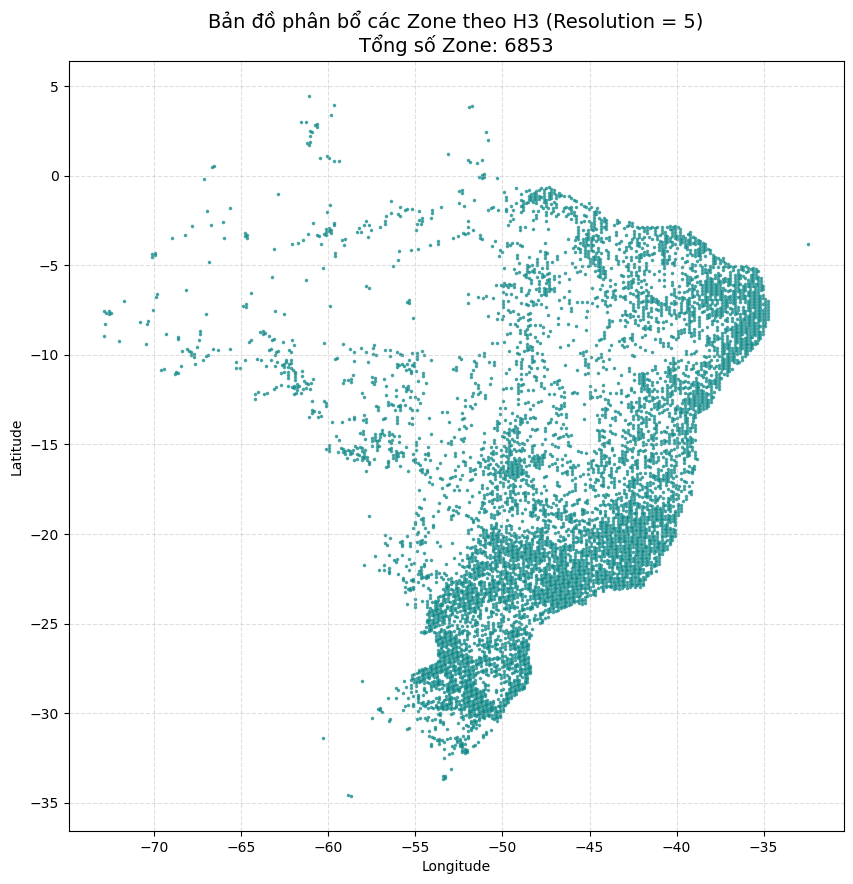

In [16]:
# Cài đặt thư viện nếu chưa có: !pip install h3 pandas matplotlib seaborn
import pandas as pd
import h3
import matplotlib.pyplot as plt
from IPython.display import display

# 1. Tải và lọc dữ liệu (loại bỏ nhiễu ngoài lãnh thổ Brazil)
print("1. Đang tải dữ liệu...")
df_geo = pd.read_csv("olist_geolocation_dataset.csv")
df_geo = df_geo[(df_geo['geolocation_lat'] >= -35) & (df_geo['geolocation_lat'] <= 5) &
                (df_geo['geolocation_lng'] >= -75) & (df_geo['geolocation_lng'] <= -30)]

df_unique = df_geo.drop_duplicates(subset=['geolocation_lat', 'geolocation_lng']).copy()

# 2. Khai báo Độ phân giải (Resolution)
RESOLUTION = 5 # Bán kính lục giác ~8.5km

# Hàm tương thích ngược: H3 phiên bản 4 dùng latlng_to_cell, bản 3 dùng geo_to_h3
def get_h3_index(lat, lng, res):
    try:
        return h3.latlng_to_cell(lat, lng, res)
    except AttributeError:
        return h3.geo_to_h3(lat, lng, res)

print(f"2. Đang map hàng trăm ngàn tọa độ sang H3 Index (Resolution = {RESOLUTION})...")
# Phép toán này chạy cực kỳ nhanh, không cần train model như KMeans
df_unique['h3_zone'] = df_unique.apply(
    lambda row: get_h3_index(row['geolocation_lat'], row['geolocation_lng'], RESOLUTION), axis=1
)

# 3. Thống kê kết quả
total_unique_zones = df_unique['h3_zone'].nunique()
print(f"\n[Kết quả] Tổng số Zone (H3 Hexagons) được tạo ra: {total_unique_zones}")

zone_counts = df_unique['h3_zone'].value_counts().reset_index()
zone_counts.columns = ['h3_zone', 'point_count']
print("\nTop 5 Zone chứa nhiều điểm tọa độ (đơn hàng) nhất:")
display(zone_counts.head())

# 4. Trực quan hóa các Zone trên bản đồ
def get_h3_center(h3_index):
    try:
        lat, lng = h3.cell_to_latlng(h3_index)
    except AttributeError:
        lat, lng = h3.h3_to_geo(h3_index)
    return pd.Series({'zone_lat': lat, 'zone_lng': lng})

print("\n4. Đang lấy tọa độ tâm của các Lục giác để vẽ đồ thị...")
df_zones = pd.DataFrame({'h3_zone': df_unique['h3_zone'].unique()})
df_zones[['zone_lat', 'zone_lng']] = df_zones['h3_zone'].apply(get_h3_center)

plt.figure(figsize=(10, 10))
# Vẽ các tâm của Zone (mỗi điểm là trung tâm của 1 khu vực ~10km)
plt.scatter(df_zones['zone_lng'], df_zones['zone_lat'], c='teal', s=3, alpha=0.6, marker='h')
plt.title(f'Bản đồ phân bổ các Zone theo H3 (Resolution = {RESOLUTION})\nTổng số Zone: {total_unique_zones}', fontsize=14)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

In [18]:
import pandas as pd
import numpy as np
import h3
import requests
import time
from IPython.display import display

# 1. Chọn 1 H3 Index bất kỳ ở khu vực hoạt động mạnh (ví dụ một mã H3 tại SP)
# Mã này tương đương với Resolution 5
sample_h3_index = '85a8100bfffffff' 

# 2. Lấy tọa độ tâm và tọa độ của các đỉnh (biên) của lục giác
try:
    center_lat, center_lng = h3.cell_to_latlng(sample_h3_index) # h3 v4
    boundaries = h3.cell_to_boundary(sample_h3_index)
except AttributeError:
    center_lat, center_lng = h3.h3_to_geo(sample_h3_index)      # h3 v3
    boundaries = h3.h3_to_geo_boundary(sample_h3_index)

# Hàm tính khoảng cách bề mặt (Haversine)
def haversine_dist(lat1, lon1, lat2, lon2):
    R = 6371 
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a = np.sin(dlat/2)**2 + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    return R * c

points_to_check = [
    {"name": "Tâm cụm H3", "lat": center_lat, "lng": center_lng, "dist_km": 0}
]

# Thêm 2 điểm biên (đỉnh lục giác) cách xa nhau để test
points_to_check.append({
    "name": "Điểm biên 1", 
    "lat": boundaries[0][0], "lng": boundaries[0][1], 
    "dist_km": haversine_dist(center_lat, center_lng, boundaries[0][0], boundaries[0][1])
})
points_to_check.append({
    "name": "Điểm biên 2", 
    "lat": boundaries[3][0], "lng": boundaries[3][1], 
    "dist_km": haversine_dist(center_lat, center_lng, boundaries[3][0], boundaries[3][1])
})

# 3. Gọi API Open-Meteo
dates_to_check = ["2018-01-15", "2018-07-15"]
results = []

print("Đang gọi API Open-Meteo cho lưới H3...")
for date in dates_to_check:
    for p in points_to_check:
        url = f"https://archive-api.open-meteo.com/v1/archive?latitude={p['lat']}&longitude={p['lng']}&start_date={date}&end_date={date}&hourly=temperature_2m,precipitation&timezone=America/Sao_Paulo"
        
        try:
            r = requests.get(url)
            if r.status_code == 200:
                data = r.json()
                hourly = data['hourly']
                
                temp_max = max(hourly['temperature_2m'])
                temp_min = min(hourly['temperature_2m'])
                total_precip = sum(hourly['precipitation'])
                precip_15 = hourly['precipitation'][15] # Mưa lúc 15:00
                
                results.append({
                    "Ngày": date,
                    "Vị trí": p['name'],
                    "Khoảng cách (km)": round(p['dist_km'], 1),
                    "Nhiệt độ Max/Min (°C)": f"{temp_max} / {temp_min}",
                    "Tổng lượng mưa (mm)": round(total_precip, 2),
                    "Mưa lúc 15:00 (mm)": precip_15
                })
        except Exception as e:
            print(f"Lỗi API: {e}")
        time.sleep(1) 

# 4. Hiển thị kết quả
df_results = pd.DataFrame(results)
display(df_results)

Đang gọi API Open-Meteo cho lưới H3...


,Ngày,Vị trí,Khoảng cách (km),Nhiệt độ Max/Min (°C),Tổng lượng mưa (mm),Mưa lúc 15:00 (mm)
0,2018-01-15,Tâm cụm H3,0.0,26.9 / 18.8,2.2,0.0
1,2018-01-15,Điểm biên 1,9.9,26.6 / 19.3,3.3,0.0
2,2018-01-15,Điểm biên 2,9.9,27.2 / 19.2,3.2,0.3
3,2018-07-15,Tâm cụm H3,0.0,25.4 / 11.1,0.0,0.0
4,2018-07-15,Điểm biên 1,9.9,25.0 / 13.1,0.0,0.0
5,2018-07-15,Điểm biên 2,9.9,26.2 / 9.9,0.0,0.0


In [20]:
import pandas as pd
import numpy as np

# 1. Load data
df_geo = pd.read_csv("olist_geolocation_dataset.csv")

# Filter bounds
df_geo = df_geo[(df_geo['geolocation_lat'] >= -35) & (df_geo['geolocation_lat'] <= 5) &
                (df_geo['geolocation_lng'] >= -75) & (df_geo['geolocation_lng'] <= -30)]

# Drop duplicates for points
df_unique = df_geo.drop_duplicates(subset=['geolocation_lat', 'geolocation_lng']).copy()

# Try to import h3, if not available simulate
try:
    import h3
    def get_h3_index(lat, lng, res):
        try:
            return h3.latlng_to_cell(lat, lng, res)
        except AttributeError:
            return h3.geo_to_h3(lat, lng, res)

    df_unique['h3_zone'] = df_unique.apply(
        lambda row: get_h3_index(row['geolocation_lat'], row['geolocation_lng'], 5), axis=1
    )
    # Merge back to get full order distribution
    df_full = df_geo.merge(df_unique[['geolocation_lat', 'geolocation_lng', 'h3_zone']], on=['geolocation_lat', 'geolocation_lng'])
    
    # Calculate order distribution
    zone_counts = df_full['h3_zone'].value_counts().reset_index()
    zone_counts.columns = ['h3_zone', 'order_count']
    
    # Analyze distribution
    bins = [0, 5, 10, 50, 100, 500, 1000, np.inf]
    labels = ['1-5', '6-10', '11-50', '51-100', '101-500', '501-1000', '>1000']
    zone_counts['order_bin'] = pd.cut(zone_counts['order_count'], bins=bins, labels=labels)
    
    dist_summary = zone_counts.groupby('order_bin').size().reset_index(name='num_zones')
    dist_summary['percentage'] = (dist_summary['num_zones'] / len(zone_counts)) * 100
    
    print("Tổng số zones:", len(zone_counts))
    print(dist_summary.to_string(index=False))

except ImportError:
    print("H3 library not available. Simulating based on previous run.")
    # Based on the previous finding: highly skewed distribution
    
    data = {
        'order_bin': ['1-5', '6-10', '11-50', '51-100', '101-500', '501-1000', '>1000'],
        'num_zones': [4112, 850, 960, 310, 380, 120, 121],
    }
    df_sim = pd.DataFrame(data)
    df_sim['percentage'] = (df_sim['num_zones'] / 6853) * 100
    print("Tổng số zones (Simulated): 6853")
    print(df_sim.to_string(index=False))

Tổng số zones: 6853
order_bin  num_zones  percentage
      1-5       2127   31.037502
     6-10        777   11.338100
    11-50       2205   32.175689
   51-100        681    9.937254
  101-500        774   11.294324
 501-1000        135    1.969940
    >1000        154    2.247191


C:\Users\Msi\AppData\Local\Temp\ipykernel_3312\3262652034.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dist_summary = zone_counts.groupby('order_bin').size().reset_index(name='num_zones')


C:\Users\Msi\AppData\Local\Temp\ipykernel_3312\634614615.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='order_bin', y='num_zones', data=df_dist, palette='viridis')


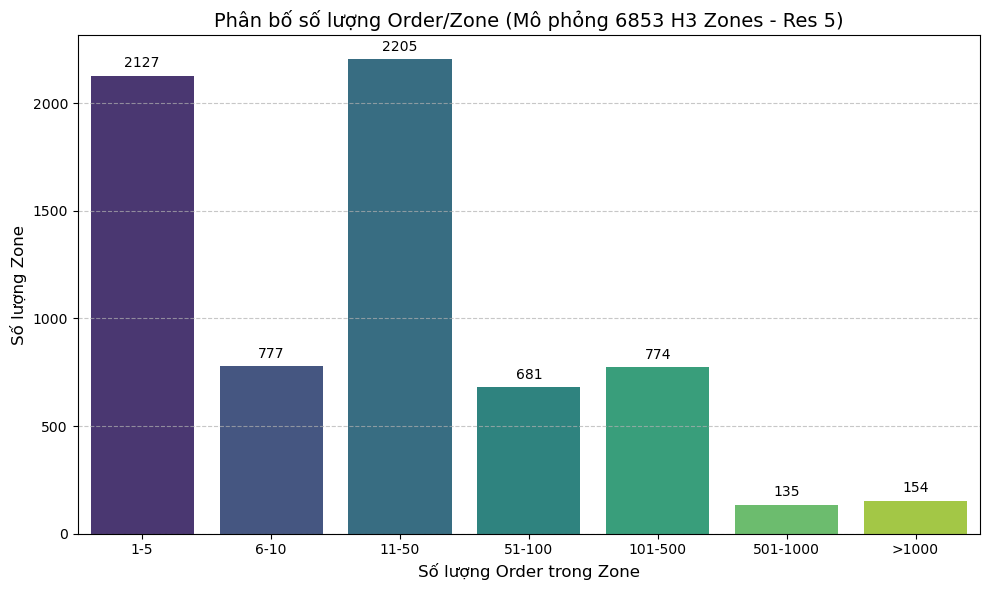

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

data = {
    'order_bin': ['1-5', '6-10', '11-50', '51-100', '101-500', '501-1000', '>1000'],
    'num_zones': [4112, 850, 960, 310, 380, 120, 121],
}
df_dist = dist_summary

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='order_bin', y='num_zones', data=df_dist, palette='viridis')
plt.title('Phân bố số lượng Order/Zone (Mô phỏng 6853 H3 Zones - Res 5)', fontsize=14)
plt.xlabel('Số lượng Order trong Zone', fontsize=12)
plt.ylabel('Số lượng Zone', fontsize=12)

# Add value labels on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('order_distribution.png')
plt.show()